# 00 — Warehouse Profile

**Business question:** What is actually in this warehouse, and is it trustworthy enough to build
staffing and quality decisions on top of?

This notebook is Phase 0: it runs before any analytical notebook that follows. Every later notebook
assumes the findings below -- gap-free date coverage, zero duplicate visits, zero implausible waits --
without re-checking them.


## Methodology

All checks read `data/er.duckdb` directly through `erops.metrics` -- the same functions the Streamlit
"Data Quality" tab calls, so this notebook and the dashboard can never disagree. Definitions of every
flag (`wait_implausible_flag`, `within_target_flag`, etc.) are in `docs/measure_spec.md`.


In [1]:
import sys
from pathlib import Path

# Make the shared erops package importable when the kernel's cwd is notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
import plotly.express as px
import plotly.io as pio

# Static PNG output so every chart renders identically in Jupyter, VS Code,
# nbviewer and GitHub's notebook preview -- no JS runtime required to view it.
pio.renderers.default = "png"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

from erops import metrics

con = metrics.get_connection()
print(f"Connected to {metrics.WAREHOUSE}")


Connected to C:\Users\dhwan\OneDrive\Desktop\PROJECTS\er-throughput-analytics\data\er.duckdb


### Mart row counts


In [2]:
row_counts = metrics.row_counts(con)
row_counts


,table,row_count
0,fct_er_visit,9216
1,agg_daily_ops,579
2,agg_hourly_arrivals,6757
3,agg_segment_waits,86
4,dim_date,579
5,dim_time_of_day,24
6,dim_patient_segment,86
7,dim_department,8


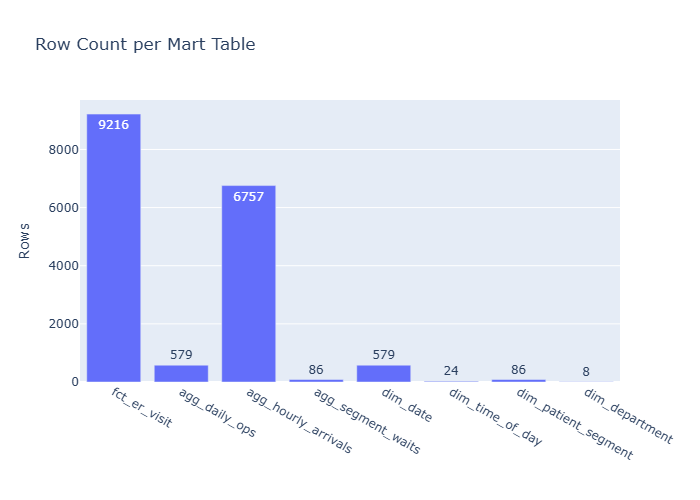

In [3]:
fig = px.bar(row_counts, x="table", y="row_count", text="row_count", title="Row Count per Mart Table")
fig.update_layout(xaxis_title="", yaxis_title="Rows")
fig.show()


`fct_er_visit` (9,216 rows) is the grain-one-row-per-visit fact table; `dim_date` and `agg_daily_ops`
both carry 579 rows, one per calendar day in the observation window -- the two tables agreeing on row
count is itself a check that the calendar spine has no gaps and no duplicate days.

> **Business decision this supports:** confirms every downstream mart is built off a single consistent
> visit population before any KPI is trusted.


### Missing-value / completeness report


In [4]:
nulls = metrics.null_and_duplicate_report(con)
nulls


,column,n_null,pct_null,n_total
0,visit_id,0,0.000000,9216
1,visit_ts,0,0.000000,9216
2,visit_date,0,0.000000,9216
3,visit_hour,0,0.000000,9216
4,segment_key,0,0.000000,9216
5,department_referral,0,0.000000,9216
6,wait_minutes,0,0.000000,9216
7,admitted_flag,0,0.000000,9216
8,satisfaction_score,6699,0.726888,9216
9,case_management_flag,0,0.000000,9216


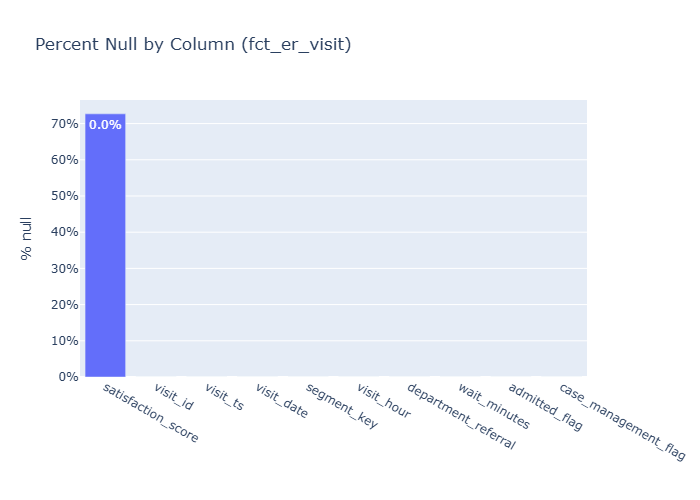

In [5]:
fig = px.bar(
    nulls.sort_values("pct_null", ascending=False),
    x="column", y="pct_null", text=nulls["pct_null"].map(lambda v: f"{v:.1%}"),
    title="Percent Null by Column (fct_er_visit)",
)
fig.update_layout(xaxis_title="", yaxis_title="% null", yaxis_tickformat=".0%")
fig.show()


Every operational column is 100% complete. The one exception is `satisfaction_score`, missing for
~73% of visits -- expected and structural (patients who don't complete the post-visit survey), not a
loading defect. Because it is the only column with material missingness, it gets its own dedicated
investigation in `05_satisfaction.ipynb` rather than being silently averaged over.

> **Business decision this supports:** any report built on `satisfaction_score` must show the response
> rate alongside it (enforced in `docs/measure_spec.md`) -- this is the evidence for why that rule exists.


### Duplicate and date-coverage checks


In [6]:
dup = metrics.duplicate_check(con)
cov = metrics.date_coverage_check(con)
inv = metrics.invalid_value_check(con)
pd.DataFrame([dup, cov, inv])


,n_rows,n_distinct_ids,n_duplicate_ids,min_date,max_date,span_days,distinct_days,gap_free,implausible_waits,negative_waits,out_of_range_satisfaction,null_admitted_flag
0,9216.0,9216.0,0.0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,2023-04-01,2024-10-30,579.0,579.0,True,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,0.0,0.0,0.0,0.0


In [7]:
print(f"Rows: {dup['n_rows']:,}  Distinct visit_id: {dup['n_distinct_ids']:,}  Duplicate ids: {dup['n_duplicate_ids']}")
print(f"Observation window: {cov['min_date'].date()} to {cov['max_date'].date()} "
      f"({cov['span_days']} calendar days, {cov['distinct_days']} distinct visit dates, "
      f"gap_free={cov['gap_free']})")
print(f"Implausible waits (> max_plausible_wait_minutes): {inv['implausible_waits']}")
print(f"Negative waits: {inv['negative_waits']}  Out-of-range satisfaction: {inv['out_of_range_satisfaction']}")


Rows: 9,216  Distinct visit_id: 9,216  Duplicate ids: 0
Observation window: 2023-04-01 to 2024-10-30 (579 calendar days, 579 distinct visit dates, gap_free=True)
Implausible waits (> max_plausible_wait_minutes): 0
Negative waits: 0  Out-of-range satisfaction: 0


Zero duplicate `visit_id` values, a perfectly gap-free 579-day calendar, and zero implausible or
negative wait values. Every visit in the source CSV reconciles 1:1 to a row in `fct_er_visit`.

> **Business decision this supports:** clears the warehouse for use as the single source of truth for
> every KPI in this project -- no adjustment or reconciliation step is needed before reporting from it.


### Categorical distributions (profile-only, not reused elsewhere)


In [8]:
# gender / race live on dim_patient_segment; department_referral / admitted_flag live on the fact table.
queries = {
    "gender": "select s.gender as value, count(*) as n from main_marts.fct_er_visit f "
              "join main_marts.dim_patient_segment s on f.segment_key = s.segment_key group by 1 order by 2 desc",
    "race": "select s.race as value, count(*) as n from main_marts.fct_er_visit f "
            "join main_marts.dim_patient_segment s on f.segment_key = s.segment_key group by 1 order by 2 desc",
    "department_referral": "select department_referral as value, count(*) as n from main_marts.fct_er_visit "
                            "group by 1 order by 2 desc",
    "admitted_flag": "select admitted_flag as value, count(*) as n from main_marts.fct_er_visit "
                      "group by 1 order by 2 desc",
}
for name, sql in queries.items():
    dist = con.execute(sql).fetchdf()
    print(f"--- {name} ---")
    print(dist.to_string(index=False))
    print()


--- gender ---
value    n
    M 4705
    F 4487
   NC   24

--- race ---
                        value    n
                        White 2571
             African American 1951
            Two or More Races 1557
                        Asian 1060
         Declined to Identify 1030
             Pacific Islander  549
Native American/Alaska Native  498

--- department_referral ---
           value    n
            None 5400
General Practice 1840
     Orthopedics  995
   Physiotherapy  276
      Cardiology  248
       Neurology  193
Gastroenterology  178
           Renal   86

--- admitted_flag ---
 value    n
  True 4612
 False 4604



Gender is effectively binary (M/F) with a small `NC` (not classified) group of 24 visits. Race has 7
categories dominated by "White". Department referral is dominated by the explicit `None` value
(no referral) at 58.6% of visits -- confirmed as a real category, not a null, during staging (see
`docs/data_dictionary.md`). Admission is close to a 50/50 split.

> **Business decision this supports:** the `NC` gender group and several small race categories are thin
> enough that any segment-level finding involving them needs a confidence interval, not a bare average
> -- this is why `06_segment_equity.ipynb` uses `agg_segment_waits`' CI columns rather than raw group means.


## Executive Summary

The warehouse is clean and internally consistent: 9,216 visits, zero duplicate identifiers, zero
implausible or negative wait values, and a gap-free 579-day calendar from 2023-04-01 to 2024-10-30.
The single material data-quality issue is the ~73% missingness on `satisfaction_score`, which is
structural (non-response) rather than a defect, and is analyzed on its own terms in notebook 05.

## Business Recommendations

- Treat every mart in this warehouse as safe to report from directly -- no additional cleaning or
  reconciliation step is required before building KPIs.
- Continue enforcing the project rule that `satisfaction_score` is never reported without its response
  rate alongside it.
- Any demographic segment analysis must carry a confidence interval or an explicit small-sample flag,
  given how thin some categories (e.g. `NC` gender, several race categories) are.

## Limitations

- This is a data-quality check, not a validity check: a clean, gap-free, duplicate-free file is
  consistent with genuine operational data, but is *also* consistent with a synthetic or curated
  teaching dataset (`docs/limitations.md` flags this dataset's provenance as unverified). Cleanliness
  this total is unusual for a real hospital extract.
- Profiling covers `fct_er_visit` and structural checks only; it does not validate the correctness of
  upstream source data entry (e.g., whether a given wait time was recorded accurately at the bedside).

## Next Steps

Proceed to `01_demand_patterns.ipynb` to characterize arrival volume, now that the underlying data is
confirmed trustworthy.
